# Case Study
- **Goal**: A farmer seeks a predictive model to determine whether the paddy yield per hectare for a given agriblock (a defined unit of agricultural land) exceeds the mean paddy yield per hectare

In [31]:
# Essential packages
import pandas as pd
import numpy as np
import seaborn as sns
import pickle
import json
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_curve, auc

In [3]:
file_name = 'Asm1_dataset26.csv'
df = pd.read_csv(file_name)
df.head(5)

,Hectares,Agriblock,Variety,Soil Types,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery,Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,...,Wind Direction_D1_D30,Wind Direction_D31_D60,Wind Direction_D61_D90,Wind Direction_D91_D120,Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
0,6,Cuddalore,CO_43,alluvial,150,75.0,dry,120,6,240,...,SW,W,NNW,WSW,72.0,78,88,85,540,35028
1,6,Kurinjipadi,ponmani,clay,150,75.0,wet,120,6,240,...,NW,S,SE,SSE,64.6,85,84,87,600,35412
2,6,Panruti,delux ponni,alluvial,150,75.0,dry,120,6,240,...,ENE,NE,NNE,W,85.0,96,84,79,600,36300
3,6,Kallakurichi,CO_43,clay,150,75.0,wet,120,6,240,...,--,WNW,SE,S,88.5,95,81,84,540,35016
4,6,Sankarapuram,ponmani,alluvial,150,75.0,dry,120,6,240,...,SSE,W,SW,NW,72.7,91,83,81,600,34044


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2789 entries, 0 to 2788
Data columns (total 45 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Hectares                            2789 non-null   int64  
 1   Agriblock                           2789 non-null   object 
 2   Variety                             2789 non-null   object 
 3   Soil Types                          2789 non-null   object 
 4   Seedrate(in Kg)                     2789 non-null   int64  
 5   LP_Mainfield(in Tonnes)             2789 non-null   float64
 6   Nursery                             2789 non-null   object 
 7   Nursery area (Cents)                2789 non-null   int64  
 8   LP_nurseryarea(in Tonnes)           2789 non-null   int64  
 9   DAP_20days                          2789 non-null   int64  
 10  Weed28D_thiobencarb                 2789 non-null   int64  
 11  Urea_40Days                         2789 no

## Task 1. Data Preparation
* What variables are included in the modelling, their roles and measurement level set and why?
* Any data issues addressed? Describe the step to transform/clean the data
* Create a new binary column named 'isAboveAvg' as the target variable, where the value is set to 1 if the paddy field per hectare exceeds the mean paddy yield per hectare, and 0 otherwise. Reorganize the dataset by removing potentially noisy or non-informative columns, such as Hectares, Paddy Yield, etc.
* Identify and remove highly correlated columns with a pairwise correlation coefficient greater than 0.98

In [4]:
# Cleaning the data
df.columns = df.columns.str.strip() # Column Hectares has a redundant space
print(f'Original dataset: {df.shape}')

# Identify duplicated rows
print(f'Number of duplicated rows: {df.duplicated().sum()}')

# Remove duplicated rows
df = df.drop_duplicates(keep='first')
print(f'Cleaned dataset: {df.shape}')

Original dataset: (2789, 45)
Number of duplicated rows: 161
Cleaned dataset: (2628, 45)


In [6]:
# Identify missing values
missing_value = df.isnull().sum()
print(f'Missing values per columns:\n{missing_value[missing_value > 0]}')

Missing values per columns:
Series([], dtype: int64)


In [7]:
# Impute missing values with its median
cols = ['Min temp_D1_D30', 'Min temp_D31_D60', 'Min temp_D61_D90', 'Min temp_D91_D120']
for col in cols:
    df[col] = df[col].fillna(df[col].median())
    print(col, df[col].unique().tolist())

# Replace '--' with NA in categorical variables
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].replace('--', 'NA')
    print(col, df[col].unique().tolist())

Min temp_D1_D30 [18.5, 19.5, 20.0, 19.0, 20.5, 18.0]
Min temp_D31_D60 [16.0, 18.5, 18.0, 17.0, 17.5, 15.5]
Min temp_D61_D90 [15.5, 17.0, 17.5, 16.5, 18.0, 15.0]
Min temp_D91_D120 [16.0, 18.0, 15.5, 16.5, 15.0]
Agriblock ['Cuddalore', 'Kurinjipadi', 'Panruti', 'Kallakurichi', 'Sankarapuram', 'Chinnasalem']
Variety ['CO_43', 'ponmani', 'delux ponni']
Soil Types ['alluvial', 'clay']
Nursery ['dry', 'wet']
Wind Direction_D1_D30 ['SW', 'NW', 'ENE', 'NA', 'SSE', 'E', 'W']
Wind Direction_D31_D60 ['W', 'S', 'NE', 'WNW', 'ENE', 'NA']
Wind Direction_D61_D90 ['NNW', 'SE', 'NNE', 'SW', 'NE', 'NA']
Wind Direction_D91_D120 ['WSW', 'SSE', 'W', 'S', 'NW', 'NNW', 'NA']


In [9]:
# Calculate the mean of the paddy yield per hectares
df['yield_per_hec'] = df['Paddy yield(in Kg)']/df['Hectares'] 
mean_yield = df['yield_per_hec'].mean()
print(f'Mean yield per hec: {mean_yield:.2f}')

# Create a column name 'isAboveAvg'
df['isAboveAvg'] = np.where(df['yield_per_hec'] > mean_yield, 1, 0)
df['isAboveAvg'].value_counts()

Mean yield per hec: 5990.15


isAboveAvg
0    1327
1    1301
Name: count, dtype: int64

In [10]:
# Check which columns are exactly proportional to Hectares
constant_ratio_cols = []
numeric_cols = df.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    # Exclude variables dropped for another reason
    if col not in ['Hectares', 'Paddy yield(in Kg)', 'yield_per_hec', 'Trash(in bundles)']:
        ratio = df[col] / df['Hectares']
        if ratio.nunique() == 1:
            constant_ratio_cols.append(col)
            unique_count = ratio.nunique()
            constant_val = ratio.iloc[0]
            print(f"{col:<35s} unique_count={unique_count:<13} constant_ratio={constant_val:.2f} <- redundant")

Seedrate(in Kg)                     unique_count=1             constant_ratio=25.00 <- redundant
LP_Mainfield(in Tonnes)             unique_count=1             constant_ratio=12.50 <- redundant
Nursery area (Cents)                unique_count=1             constant_ratio=20.00 <- redundant
LP_nurseryarea(in Tonnes)           unique_count=1             constant_ratio=1.00 <- redundant
DAP_20days                          unique_count=1             constant_ratio=40.00 <- redundant
Weed28D_thiobencarb                 unique_count=1             constant_ratio=2.00 <- redundant
Micronutrients_70Days               unique_count=1             constant_ratio=15.00 <- redundant
Pest_60Day(in ml)                   unique_count=1             constant_ratio=600.00 <- redundant


In [11]:
# Drop noisy columns
drop_cols = ['Hectares', 'Paddy yield(in Kg)', 'yield_per_hec', 'Trash(in bundles)'] + constant_ratio_cols
df_clean = df.drop(columns = drop_cols)
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2628 entries, 0 to 2788
Data columns (total 35 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Agriblock                           2628 non-null   object 
 1   Variety                             2628 non-null   object 
 2   Soil Types                          2628 non-null   object 
 3   Nursery                             2628 non-null   object 
 4   Urea_40Days                         2628 non-null   float64
 5   Potassh_50Days                      2628 non-null   float64
 6   30DRain( in mm)                     2628 non-null   float64
 7   30DAI(in mm)                        2628 non-null   float64
 8   30_50DRain( in mm)                  2628 non-null   float64
 9   30_50DAI(in mm)                     2628 non-null   float64
 10  51_70DRain(in mm)                   2628 non-null   float64
 11  51_70AI(in mm)                      2628 non-nul

In [13]:
# Correlation Analysis
## Encode categorical columns with One-hot encoding
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

# Separate input and target variables
X = df_encoded.drop(columns=['isAboveAvg'])
y = df_encoded['isAboveAvg']

corr_matrix = X.corr().abs()

# Find highly correlated pair-wise columns
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [col for col in upper_triangle.columns if any(upper_triangle[col] > 0.98)]

print(f"Highly correlated columns to drop {len(high_corr_cols)}:")
for col in high_corr_cols:
    pairs = upper_triangle.index[upper_triangle[col] > 0.98].tolist()
    for pair in pairs:
        print(f" {pair} <-> {col}: r = {upper_triangle.loc[pair, col]:.4f}")

# Drop highly correlated columns
df_final = X.drop(columns=high_corr_cols)
print(f"Final feature set: {df_final.shape}")

Highly correlated columns to drop 7:
 Urea_40Days <-> Potassh_50Days: r = 1.0000
 30DRain( in mm) <-> 30DAI(in mm): r = 1.0000
 30_50DRain( in mm) <-> 30_50DAI(in mm): r = 1.0000
 51_70DRain(in mm) <-> 51_70AI(in mm): r = 1.0000
 30_50DRain( in mm) <-> 71_105DRain(in mm): r = 1.0000
 30_50DAI(in mm) <-> 71_105DRain(in mm): r = 1.0000
 30_50DRain( in mm) <-> 71_105DAI(in mm): r = 1.0000
 30_50DAI(in mm) <-> 71_105DAI(in mm): r = 1.0000
 71_105DRain(in mm) <-> 71_105DAI(in mm): r = 1.0000
 Min temp_D1_D30 <-> Min temp_D61_D90: r = 0.9923
Final feature set: (2628, 50)


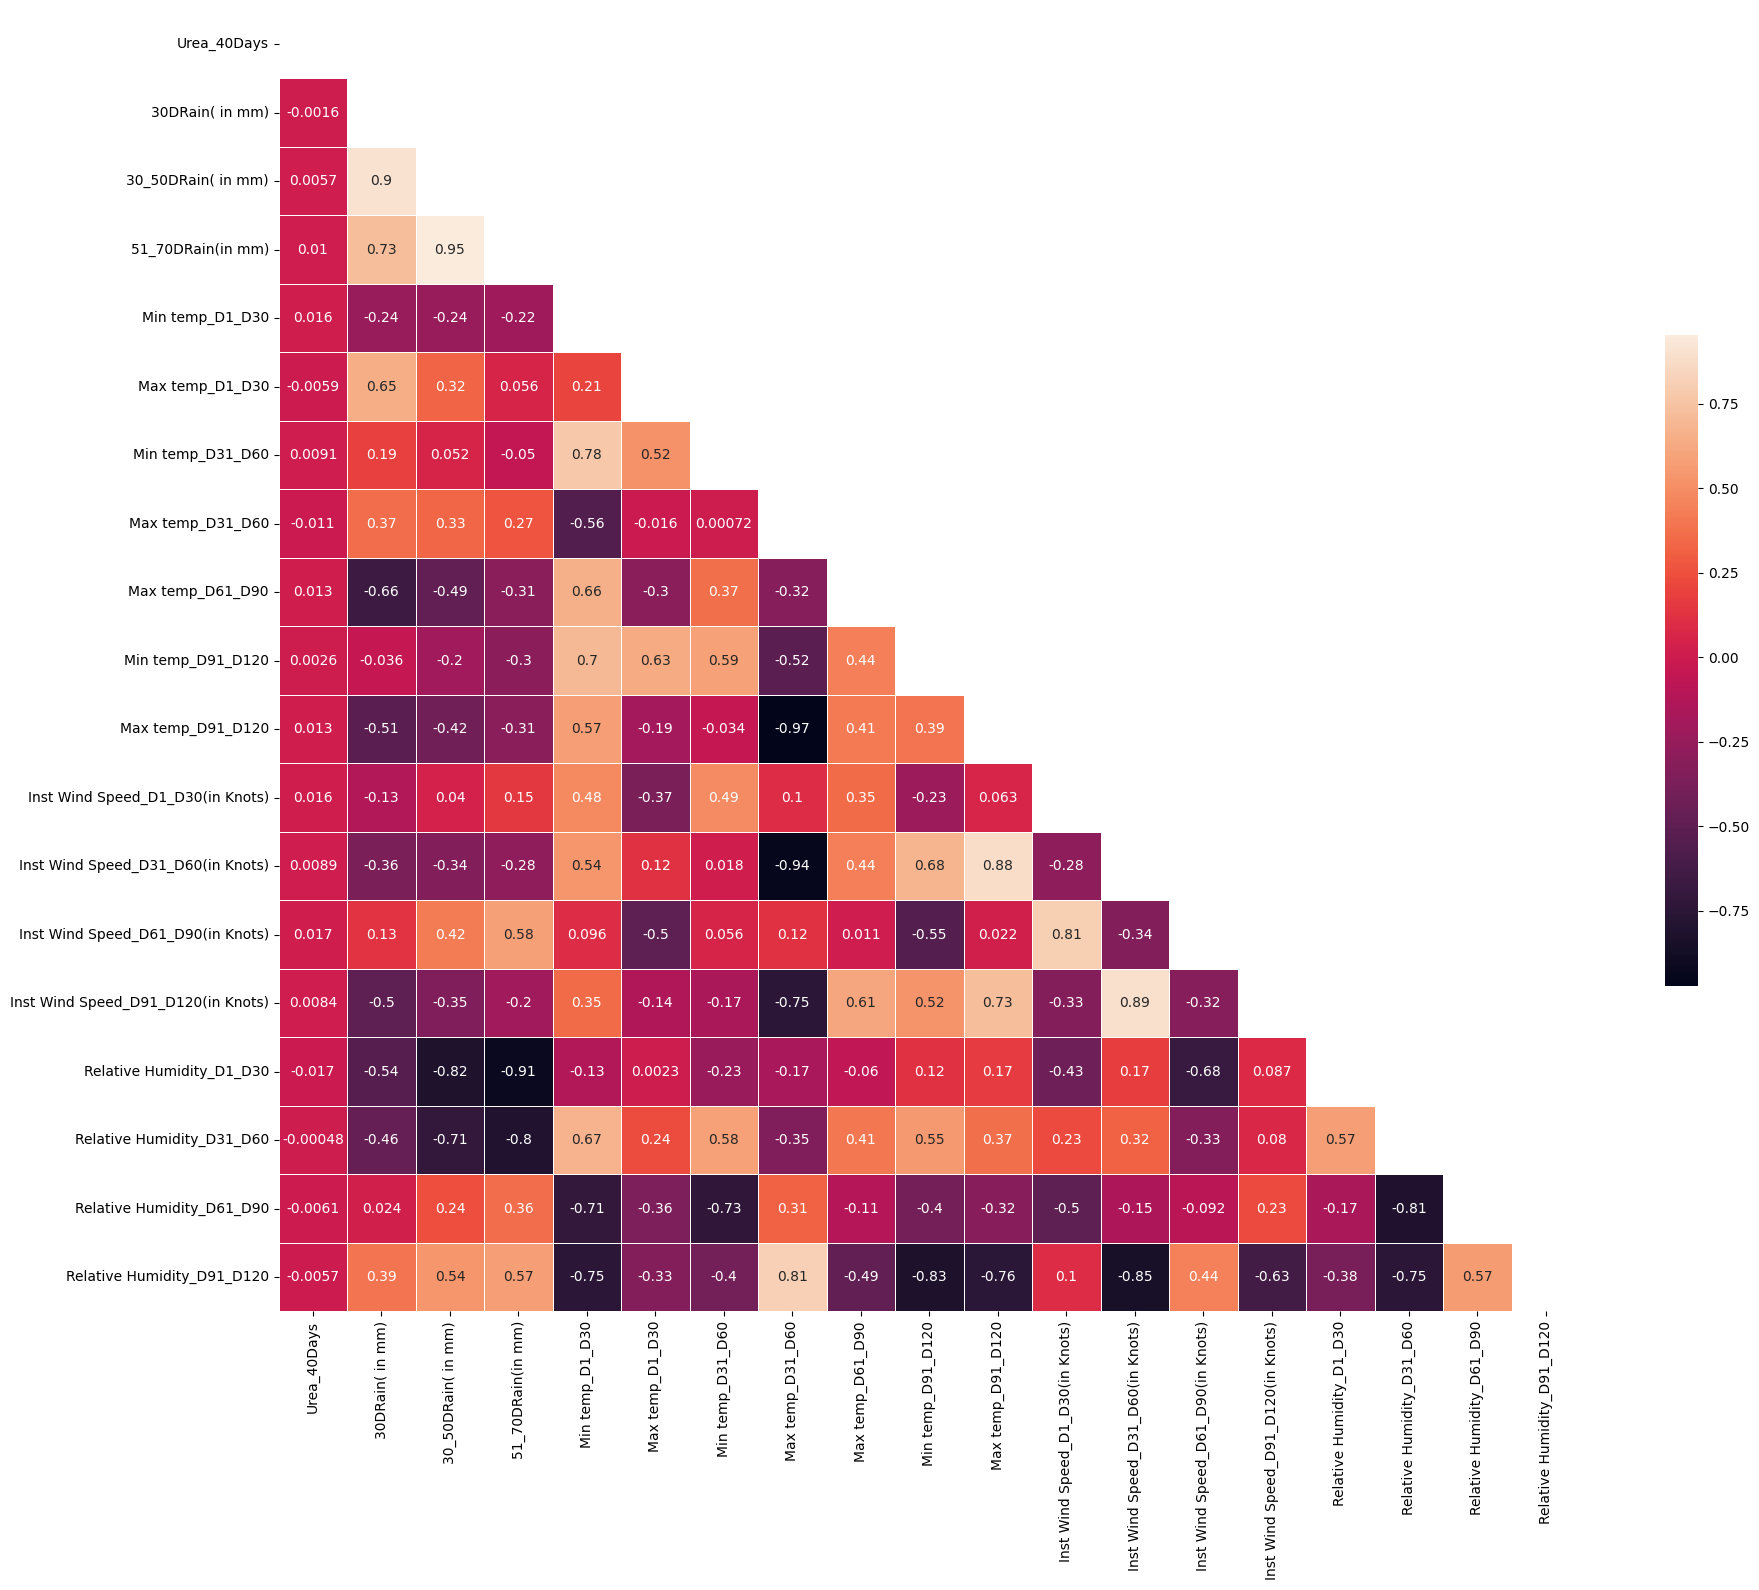

In [14]:
# Correlation Heatmap (After Cleaning)
numeric_df = df_final.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, mask=mask, square=True, linewidths=0.5, cbar_kws={"shrink": 0.5}, annot=True)
plt.tight_layout()
plt.show()

## Task 2. Decision Tree modelling (4 marks)
* Build a decision tree using the default setting, examine the tree results and answer the questions:
    * What parameters have been used to build the tree? Detail them
    * What data split was used to create training and test datasets?
    * What is the classification accuracy on the training and test datasets?
    * What is the size of the tree (number of nodes and rules)?
    * Which variables is used for the first split? What are the variables that are used for the second split?
    * What are the 10 important variables in build the tree?
* Build another decision tree tuned with GridSearchCV. Examine the result:
    * What are the optimal parameters for this decision tree? Explain your choice of hyperparameters to search, and the chosen search range(s)?
    * What is the classification accuracy on the training the test datasets?
    * What is the size of the chosen tree (number of nodes and rules)?
    * Which variable is used for the first split? What are the variables that are used for the 2nd split?
    * What are the 10 important variables in building the tree?
    * Report which decision tree model exhibits significant evidence of overfitting 
* What is the significant difference between these 2 decision tree models? Visualize the trees and list some of the rules where the class is positive (target variable = 1)
* Produce the ROC curve for both decision tree models. Compare the performance of the 2 models and analyze the key variables (features) they utilize

### 2.1. Decision Tree with default setting

In [15]:
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(df_final, y, test_size=0.3, 
                                                    random_state=RANDOM_STATE, stratify=y)

print("Size of training set:", len(X_train))
print("Size of testing set:", len(X_test))

Size of training set: 1839
Size of testing set: 789


In [16]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Q1. What parameters have been used to build the tree?

In [17]:
for p, v in clf.get_params().items():
    print(f'{p}: {v}')

ccp_alpha: 0.0
class_weight: None
criterion: gini
max_depth: None
max_features: None
max_leaf_nodes: None
min_impurity_decrease: 0.0
min_samples_leaf: 1
min_samples_split: 2
min_weight_fraction_leaf: 0.0
monotonic_cst: None
random_state: 42
splitter: best


Q2. What data split was used to create training and test datasets?

In [18]:
train_size = (len(X_train) / len(df_final)) * 100
test_size = 100 - train_size
print(f'Train size: {train_size:.2f}%')
print(f'Test size: {test_size:.2f}%')

Train size: 69.98%
Test size: 30.02%


Q3. What is the classification accuracy on the training and test datatset?

In [19]:
train_acc = accuracy_score(y_train, clf.predict(X_train)) * 100
test_acc = accuracy_score(y_test, clf.predict(X_test)) * 100
print(f'Training accuracy: {train_acc:.2f}%\nTest accuracy: {test_acc:.2f}%')

Training accuracy: 93.69%
Test accuracy: 83.02%


Q4. What is the size of the tree (number of nodes and rules)?

In [20]:
print(f'Total nodes: {clf.tree_.node_count} nodes')
print(f'Rules: {clf.tree_.n_leaves} leaves')

Total nodes: 509 nodes
Rules: 255 leaves


Q5. Which variable is used for the first split? What are the variables that are used for the second split?

In [21]:
tree = clf.tree_
feature_names = X_train.columns
first_feature = feature_names[tree.feature[0]]
left_child = tree.children_left[0]
right_child = tree.children_right[0]
print(f'First split: {first_feature}')
print(f'Second split:')
print(f'Left: {feature_names[tree.feature[left_child]]}')
print(f'Right: {feature_names[tree.feature[right_child]]}')

First split: Urea_40Days
Second split:
Left: Wind Direction_D31_D60_W
Right: Urea_40Days


Q6. What are the 10 important features in building the tree?

In [22]:
important_features = pd.DataFrame({'Feature': feature_names, 'Importance': clf.feature_importances_})
important_features.sort_values(by='Importance', ascending=False).head(10)

,Feature,Importance
0,Urea_40Days,0.815453
24,Variety_delux ponni,0.031702
25,Variety_ponmani,0.025408
27,Nursery_wet,0.024829
26,Soil Types_clay,0.023788
6,Min temp_D31_D60,0.006968
2,30_50DRain( in mm),0.005815
9,Min temp_D91_D120,0.005327
29,Wind Direction_D1_D30_NA,0.005065
34,Wind Direction_D31_D60_NA,0.003985


### 2.2. Decision tree tuned with GridSearchCV

2.2.a. What are the optimal parameters for this decision tree? Explain your choice of hyperparameters to search, and the chosen search range(s)?

In [24]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 3, 5, 7, 10, 15],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10]
}

dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_clf = grid_search.best_estimator_
print(f'Optimal Parameters:\n{grid_search.best_params_}')

Optimal Parameters:
{'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


Reasoning:
- 'gini' and 'entropy' are the 2 standard impurity metrics and there are no other metrics
- 'max_depth':
    + 'None' to see if the other constrains (e.g. min_samples_*) could fix the tree on their own
    + [3, 5, 7, 10, 15] are the standard and small range to immediately avoid overfit
- 'min_samples_split' & 'min_samples_leaf': we use the recommend default range searched on the internet

2.2.b. What is the classification accuracy on the training and test datasets?

In [25]:
train_acc = accuracy_score(y_train, best_clf.predict(X_train)) * 100
test_acc = accuracy_score(y_test, best_clf.predict(X_test)) * 100
print(f'Training accuracy: {train_acc:.2f}%')
print(f'Test accuracy: {test_acc:.2f}%')

Training accuracy: 90.32%
Test accuracy: 90.24%


2.2.b. What is the size of the chosen tree (number of nodes and rules)?

In [26]:
print(f'Number of nodes: {best_clf.tree_.node_count} nodes')
print(f'Number of rules: {best_clf.tree_.n_leaves} leaves')

Number of nodes: 13 nodes
Number of rules: 7 leaves


2.2.c. What variable is used for the first split? What are the variables that are used for the second split?

In [27]:
tree = best_clf.tree_
feature_names = X_train.columns
first_feature = feature_names[tree.feature[0]]
left_child = tree.children_left[0]
right_child = tree.children_right[0]
print(f'First split: {first_feature}')
print(f'Second split:')
print(f'Left: {feature_names[tree.feature[left_child]]}')
print(f'Right: {feature_names[tree.feature[right_child]]}')

First split: Urea_40Days
Second split:
Left: Wind Direction_D31_D60_W
Right: Urea_40Days


2.2.d. What are the 10 important variables in building a tree?

In [28]:
important_features = pd.DataFrame({'Feature': feature_names, 'Importance': best_clf.feature_importances_})
important_features.sort_values(by='Importance', ascending=False).head(10)

,Feature,Importance
0,Urea_40Days,0.968638
24,Variety_delux ponni,0.030974
25,Variety_ponmani,0.000266
37,Wind Direction_D31_D60_W,0.000123
2,30_50DRain( in mm),0.000000
5,Max temp_D1_D30,0.000000
6,Min temp_D31_D60,0.000000
3,51_70DRain(in mm),0.000000
4,Min temp_D1_D30,0.000000
9,Min temp_D91_D120,0.000000


2.2.e. Report which decision tree model exhibits significant evidence of overfitting

* The Default Tree exhibits significant overfitting as the accuracy gap between the training (93.69%) and test (83.02%) is high (~10.67%). Whereas, in the second tuned tree using GridSearchCV, the gap is smaller
(~0.08%) with training accuracy and test accuracy are 90.32% and 90.24% respectively

* Furthermore, the first tree created 255 hyper-specific rules (leaves) to perfectly categorize the training data. The second tree achieved a better accuracy using only 7 rules (~only 2% of the default tree).

### 3. What is the significant difference between these two decision tree models – default (Task 2.1) and using GridSearchCV (Task 2.2)? Visualize the trees and list some of the rules where the class is positive (the target variable = 1).

The fundamental difference between the Default Decision Tree and the GridSearchCV Tuned Decision Tree comes down to Overfitting versus Generalization:

* The Default Tree (Unconstrained): It was allowed to grow to an infinite depth until every single leaf node was perfectly pure. This resulted in a massive, overly complex tree (255 rules). It simply memorized the training data (capturing noise and outliers), which caused its accuracy to drop significantly when tested on unseen data.

* The Tuned Tree (Constrained): By enforcing hyperparameters like max_depth=3 and min_samples_split=2, we forced the tree to stop growing early. This pruned away the hyper-specific, noisy rules and left only the broadest, most reliable patterns. It is mathematically simpler (only 7 rules) but performs much better on new data.

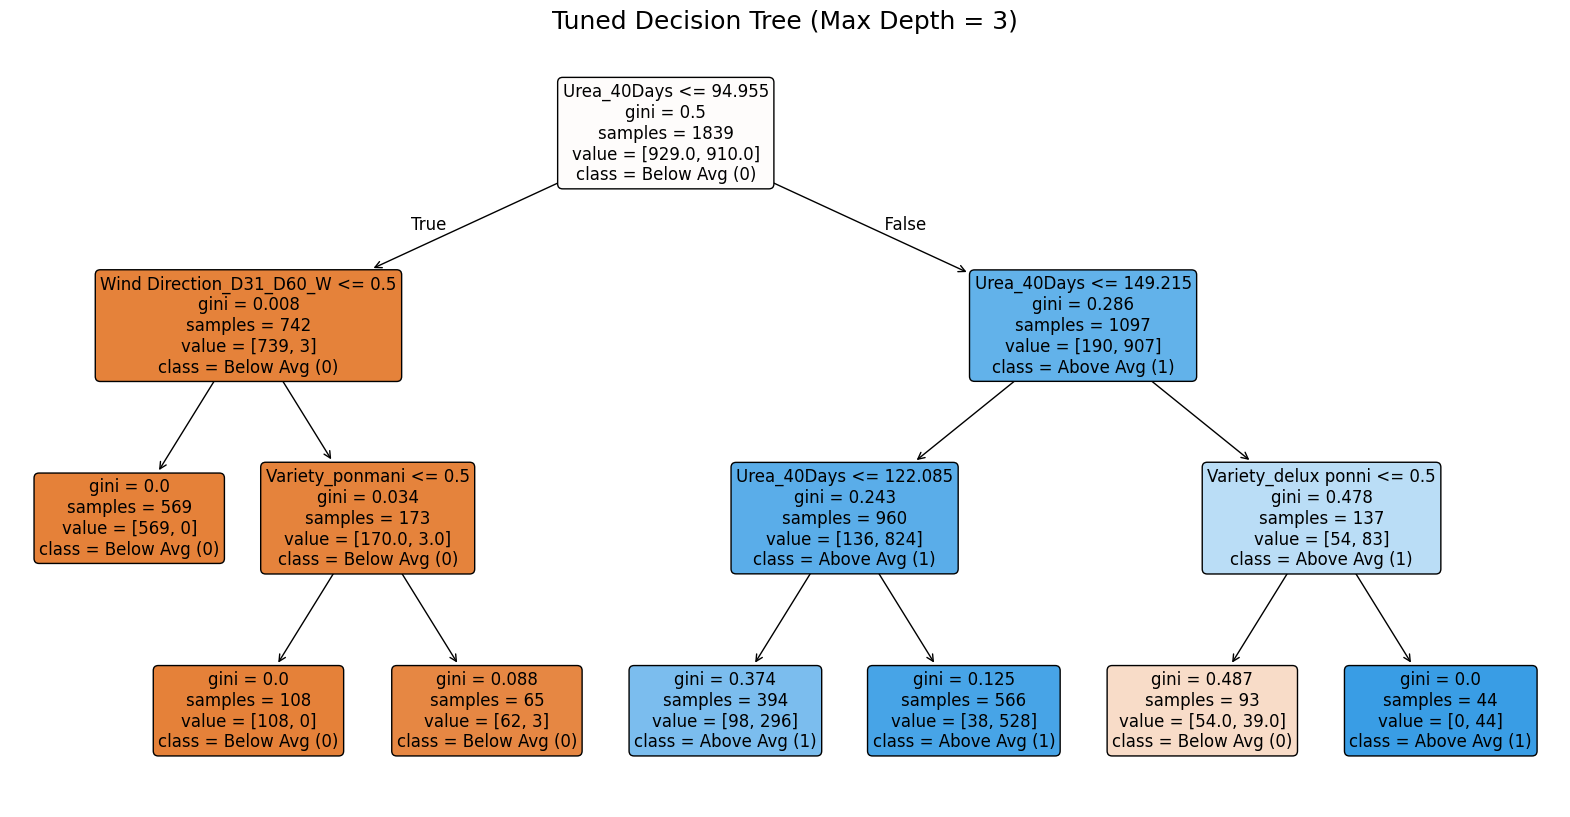

In [29]:
# Set up a figure
plt.figure(figsize=(20, 10))

# Plot the tuned tree
plot_tree(best_clf, 
          feature_names=X_train.columns, 
          class_names=['Below Avg (0)', 'Above Avg (1)'], 
          filled=True, 
          rounded=True, 
          fontsize=12)

plt.title("Tuned Decision Tree (Max Depth = 3)", fontsize=18)
plt.show()

### 4. Produce the ROC curve for both decision tree models. Compare the performance of the two models and analyze the key variables (features) they utilize.

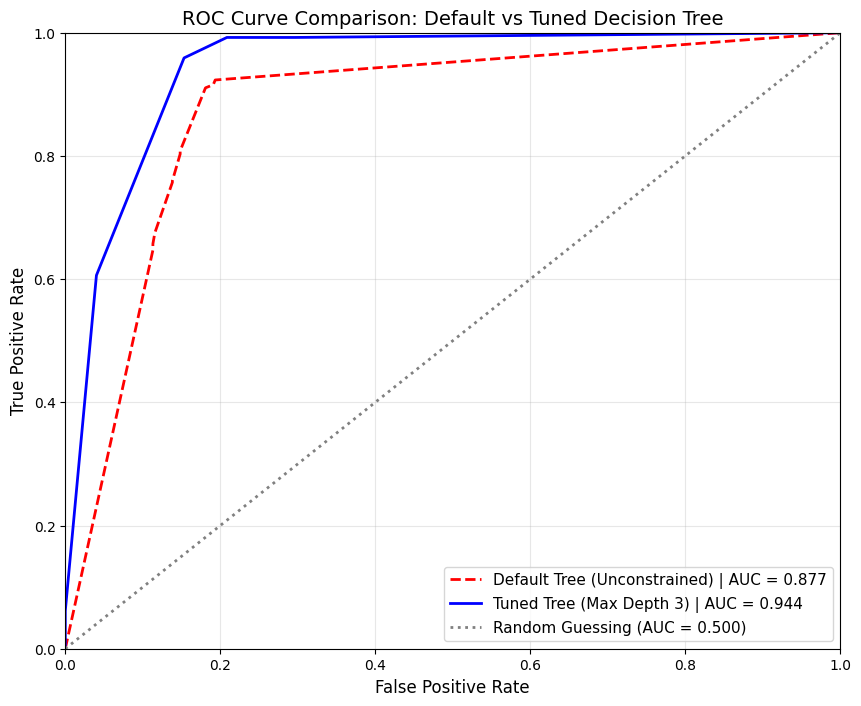

In [30]:
y_prob_default = clf.predict_proba(X_test)[:, 1]
y_prob_tuned = best_clf.predict_proba(X_test)[:, 1]

# Calculate FPR, TPR, AUC for default tree
fpr_def, tpr_def, _ = roc_curve(y_test, y_prob_default)
auc_def = auc(fpr_def, tpr_def)

# Calculate FPR, TPR, AUC for tuned tree
fpr_tun, tpr_tun, _ = roc_curve(y_test, y_prob_tuned)
auc_tun = auc(fpr_tun, tpr_tun)

# ROC plotting
plt.figure(figsize=(10, 8))

# Default Tree
plt.plot(fpr_def, tpr_def, color='red', lw=2, linestyle='--',
         label=f'Default Tree (Unconstrained) | AUC = {auc_def:.3f}')

# Tuned Tree
plt.plot(fpr_tun, tpr_tun, color='blue', lw=2, 
         label=f'Tuned Tree (Max Depth 3) | AUC = {auc_tun:.3f}')

# Baseline
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle=':', label='Random Guessing (AUC = 0.500)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison: Default vs Tuned Decision Tree', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)

plt.show()

In [32]:
# Save final_df and best params for later tasks
df_final.to_csv('df_final_features.csv', index=False)

with open('best_dt_params.json', 'w') as f:
    json.dump(grid_search.best_params_, f, indent=2, default=str)